# Tesla Stock Price Prediction
### Using SimpleRNN and LSTM with Multi-Horizon Forecasting (1, 5, 10 days)

**Domain:** Financial Services  
**Dataset:** TSLA.csv — Tesla historical stock prices (June 2010 – February 2020)  
**Goal:** Build and compare SimpleRNN vs LSTM models to predict Tesla's closing price at 1-day, 5-day, and 10-day horizons.

---
**Project Pipeline:**
1. Data Loading & EDA
2. Data Cleaning & Preprocessing
3. Feature Engineering
4. Sequence Creation for Time-Series
5. Hyperparameter Tuning (Grid Search)
6. Model Training (SimpleRNN + LSTM × 3 horizons)
7. Evaluation & Comparison
8. Summary & Insights

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import math
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import ParameterGrid

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully!")

TensorFlow version: 2.19.0
All libraries loaded successfully!


## 2. Load Dataset

In [4]:
# Load from CSV (or use files.upload() for Colab)
# from google.colab import files
# uploaded = files.upload()   # upload TSLA.csv
from google.colab import files
uploaded = files.upload()
df = pd.read_excel("TSLA.xlsx")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Saving TSLA.xlsx to TSLA (2).xlsx
Shape: (2416, 7)

First 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [5]:
print("Data Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Data Types:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

Basic Statistics:


,Date,Open,High,Low,Close,Adj Close,Volume
count,2416,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,2015-04-15 11:09:56.026490112,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
min,2010-06-29 00:00:00,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,2012-11-19 18:00:00,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,2015-04-16 12:00:00,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,2017-09-07 06:00:00,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,2020-02-03 00:00:00,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07
std,NaN,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06


## 3. Data Cleaning & Preprocessing

In [6]:
# Convert Date to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Handle missing values
# For time-series stock data, forward fill is preferred over mean/median
# because each day's price is closely related to the previous day.
# Mean imputation would distort the temporal pattern.
df.ffill(inplace=True)   # forward fill — primary strategy
df.bfill(inplace=True)   # back fill — handles any leading NaNs at start of series

print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nDate range:", df.index.min(), "→", df.index.max())
print("Cleaned shape:", df.shape)

Missing values per column:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values after cleaning:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Date range: 2010-06-29 00:00:00 → 2020-02-03 00:00:00
Cleaned shape: (2416, 6)


## 4. Exploratory Data Analysis (EDA)

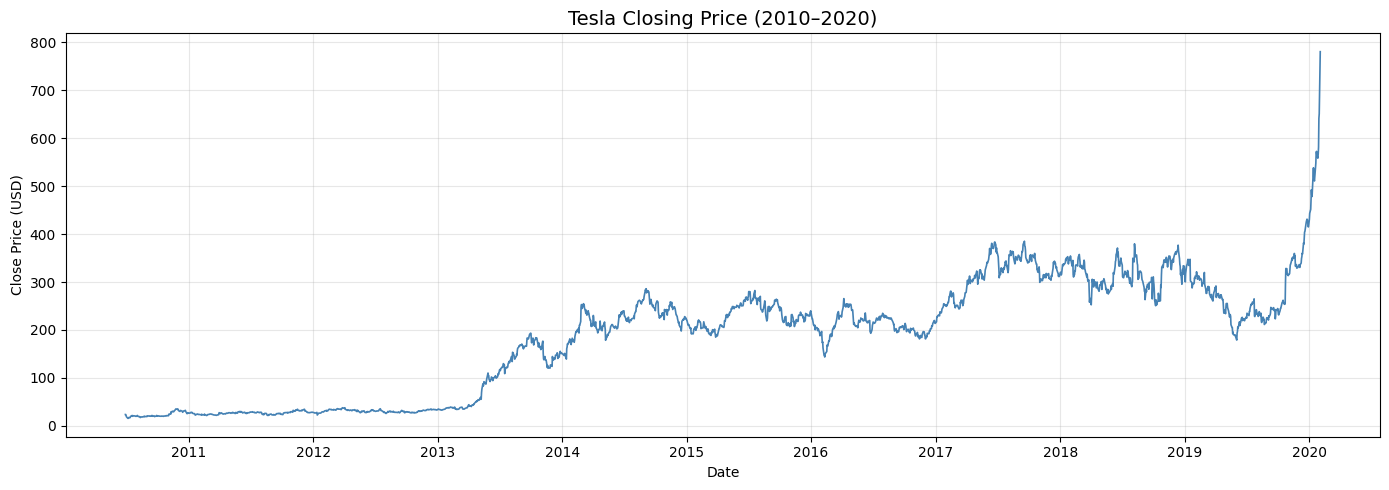

In [7]:
# --- Closing Price Over Time ---
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], color='steelblue', linewidth=1.2)
plt.title('Tesla Closing Price (2010–2020)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('close_price.png', dpi=150)
plt.show()

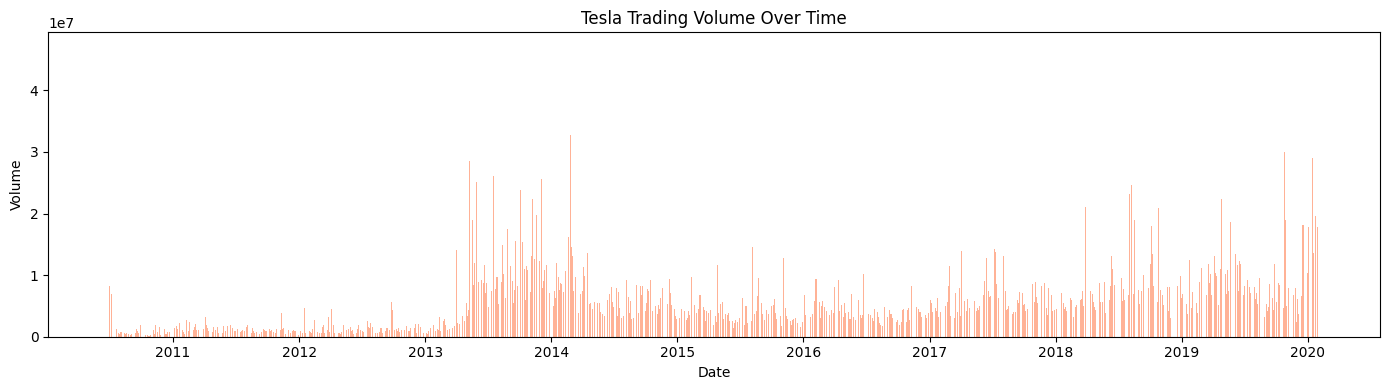

In [8]:
# --- Trading Volume Over Time ---
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['Volume'], color='coral', alpha=0.6)
plt.title('Tesla Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

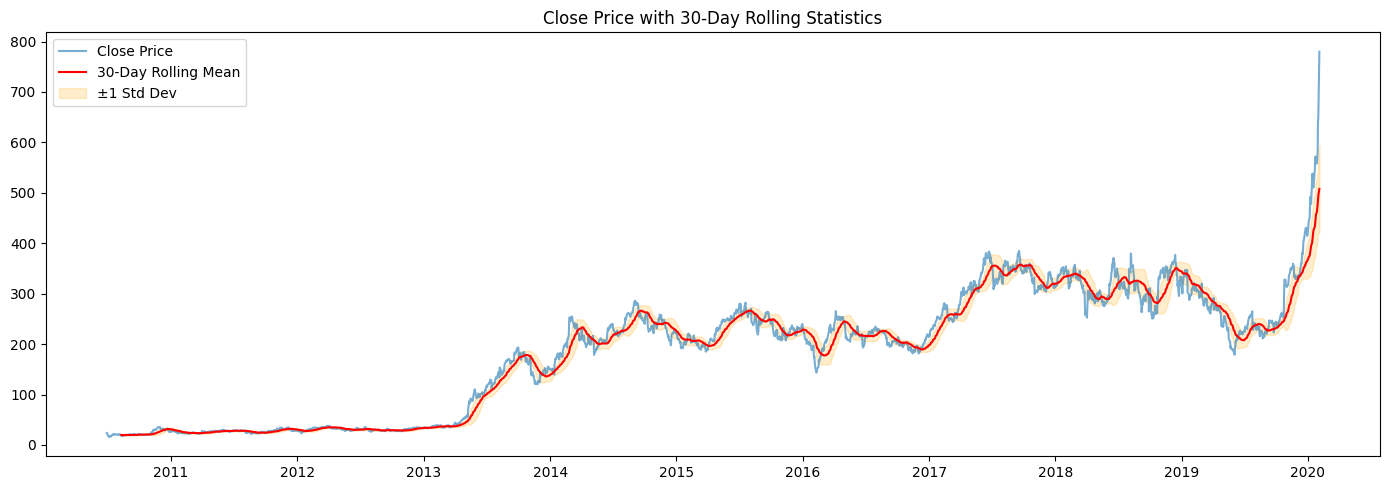

In [9]:
# --- Rolling Statistics (30-day) ---
df['Rolling_Mean_30'] = df['Close'].rolling(window=30).mean()
df['Rolling_Std_30']  = df['Close'].rolling(window=30).std()

plt.figure(figsize=(14, 5))
plt.plot(df['Close'], label='Close Price', alpha=0.6)
plt.plot(df['Rolling_Mean_30'], label='30-Day Rolling Mean', color='red')
plt.fill_between(df.index,
                 df['Rolling_Mean_30'] - df['Rolling_Std_30'],
                 df['Rolling_Mean_30'] + df['Rolling_Std_30'],
                 alpha=0.2, color='orange', label='±1 Std Dev')
plt.title('Close Price with 30-Day Rolling Statistics')
plt.legend()
plt.tight_layout()
plt.show()

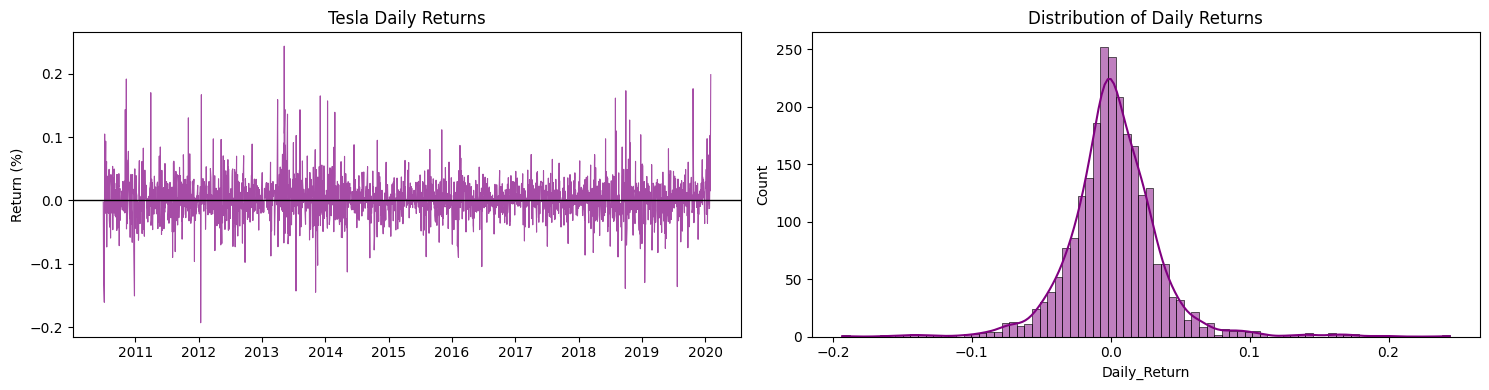

Mean Daily Return : 0.0020
Std Dev (Volatility): 0.0328
Max Daily Gain    : 0.2440
Max Daily Loss    : -0.1933


In [10]:
# --- Daily Returns ---
df['Daily_Return'] = df['Close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(df['Daily_Return'], color='purple', alpha=0.7, linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Tesla Daily Returns')
axes[0].set_ylabel('Return (%)')

sns.histplot(df['Daily_Return'].dropna(), bins=80, kde=True, color='purple', ax=axes[1])
axes[1].set_title('Distribution of Daily Returns')

plt.tight_layout()
plt.show()

# Volatility summary
print(f"Mean Daily Return : {df['Daily_Return'].mean():.4f}")
print(f"Std Dev (Volatility): {df['Daily_Return'].std():.4f}")
print(f"Max Daily Gain    : {df['Daily_Return'].max():.4f}")
print(f"Max Daily Loss    : {df['Daily_Return'].min():.4f}")

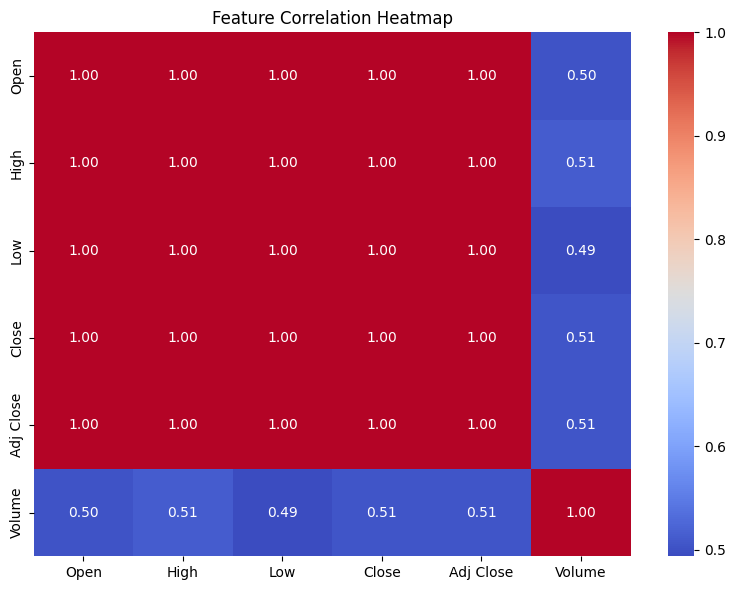

Note: Open, High, Low, Close, Adj Close are all highly correlated (>0.99)
Volume shows much weaker correlation with price features.


In [11]:
# --- Correlation Heatmap ---
plt.figure(figsize=(8, 6))
corr = df[['Open','High','Low','Close','Adj Close','Volume']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print("Note: Open, High, Low, Close, Adj Close are all highly correlated (>0.99)")
print("Volume shows much weaker correlation with price features.")

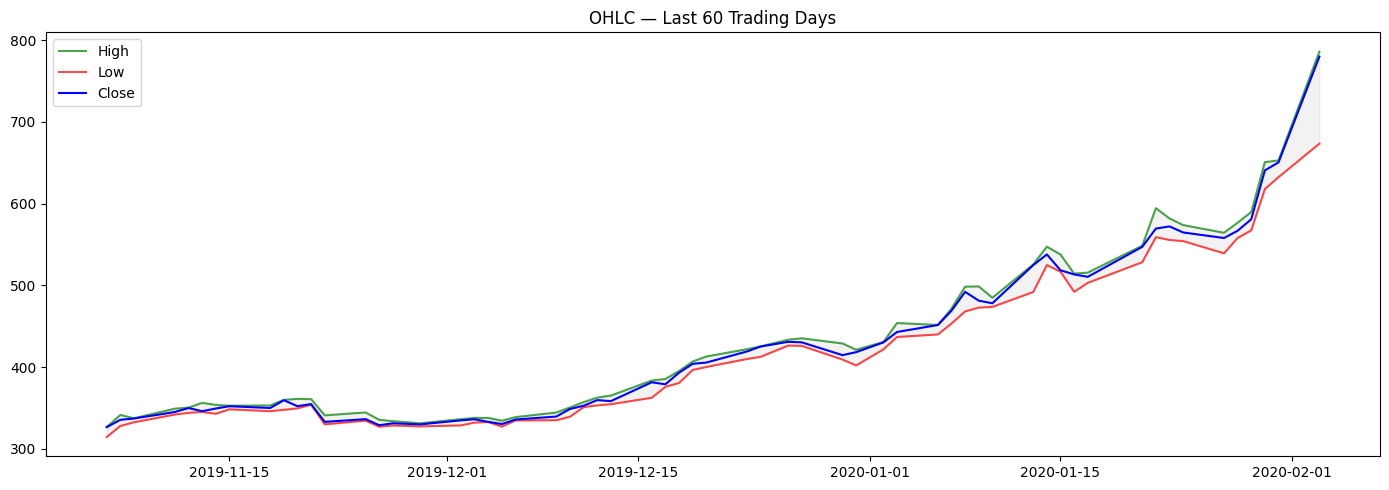

In [12]:
# --- OHLC Last 60 Days ---
fig, ax = plt.subplots(figsize=(14, 5))
sample = df.tail(60)
ax.plot(sample.index, sample['High'], label='High', color='green', alpha=0.7)
ax.plot(sample.index, sample['Low'],  label='Low',  color='red',   alpha=0.7)
ax.plot(sample.index, sample['Close'],label='Close',color='blue',  linewidth=1.5)
ax.fill_between(sample.index, sample['Low'], sample['High'], alpha=0.1, color='grey')
ax.set_title('OHLC — Last 60 Trading Days')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Feature Engineering

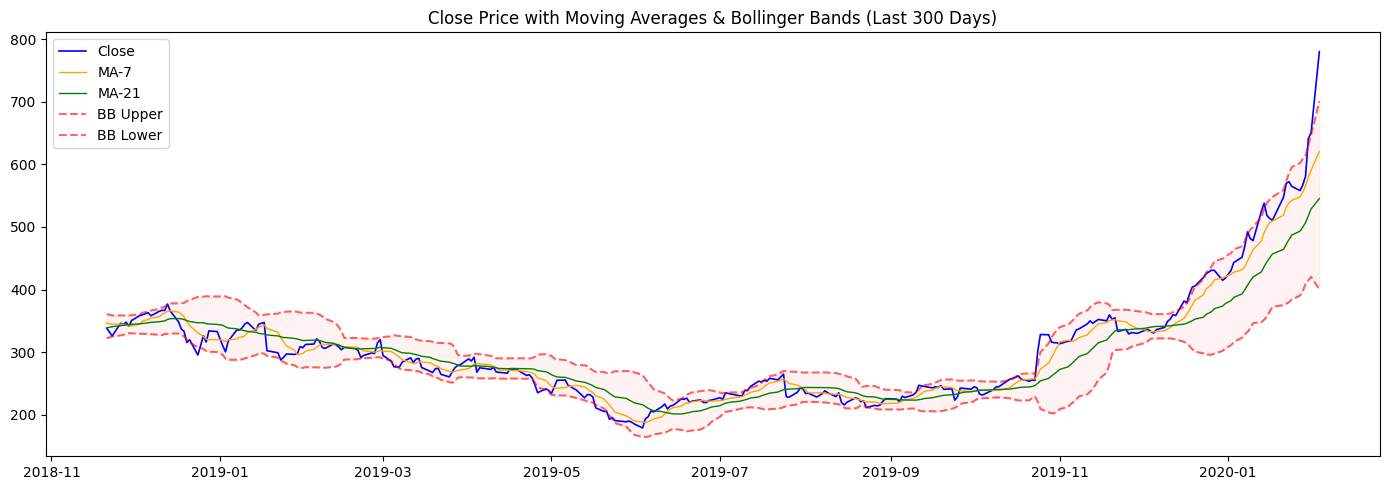

Modelling data shape: (2416, 1)


In [13]:
# As per project guidelines, analysis is performed on the Closing Price.
# We add a few technical indicator features for context and EDA.

# 7-day and 21-day moving averages
df['MA_7']  = df['Close'].rolling(window=7).mean()
df['MA_21'] = df['Close'].rolling(window=21).mean()

# Bollinger Bands (20-day)
df['BB_Mid']   = df['Close'].rolling(window=20).mean()
df['BB_Upper'] = df['BB_Mid'] + 2 * df['Close'].rolling(window=20).std()
df['BB_Lower'] = df['BB_Mid'] - 2 * df['Close'].rolling(window=20).std()

# Plot MA and Bollinger Bands on recent 300 days
fig, ax = plt.subplots(figsize=(14, 5))
recent = df.tail(300)
ax.plot(recent.index, recent['Close'],    label='Close',    color='blue',   linewidth=1.2)
ax.plot(recent.index, recent['MA_7'],     label='MA-7',     color='orange', linewidth=1)
ax.plot(recent.index, recent['MA_21'],    label='MA-21',    color='green',  linewidth=1)
ax.plot(recent.index, recent['BB_Upper'], label='BB Upper', color='red',    linestyle='--', alpha=0.6)
ax.plot(recent.index, recent['BB_Lower'], label='BB Lower', color='red',    linestyle='--', alpha=0.6)
ax.fill_between(recent.index, recent['BB_Lower'], recent['BB_Upper'], alpha=0.05, color='red')
ax.set_title('Close Price with Moving Averages & Bollinger Bands (Last 300 Days)')
ax.legend()
plt.tight_layout()
plt.show()

# For modelling, use only Close price (univariate — project requirement)
data = df[['Close']].copy()
print("Modelling data shape:", data.shape)

## 6. Data Preprocessing for Deep Learning

In [14]:
# Scale data to [0, 1] — required for RNN/LSTM convergence
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Train/Test split (80/20) — no shuffle for time-series
train_size = int(len(scaled_data) * 0.80)
train_data = scaled_data[:train_size]
test_data  = scaled_data[train_size:]

print(f"Total samples : {len(scaled_data)}")
print(f"Train samples : {len(train_data)}")
print(f"Test samples  : {len(test_data)}")

Total samples : 2416
Train samples : 1932
Test samples  : 484


In [15]:
def create_sequences(dataset, window_size, forecast_horizon=1):
    """
    Creates input-output sequences for time-series modelling.

    Args:
        dataset         : Scaled 1D array of closing prices
        window_size     : Number of past days used as input features
        forecast_horizon: How many days ahead to predict (1, 5, or 10)

    Returns:
        X (inputs), y (targets) as numpy arrays
    """
    X, y = [], []
    for i in range(len(dataset) - window_size - forecast_horizon + 1):
        X.append(dataset[i : i + window_size, 0])
        y.append(dataset[i + window_size + forecast_horizon - 1, 0])
    return np.array(X), np.array(y)


WINDOW_SIZE = 60   # use past 60 days to predict

# Create sequences for all 3 forecast horizons
# IMPORTANT: We create sequences from the FULL data (train+test combined)
# and slice correctly to avoid leakage while maintaining proper sequence boundaries
full_data = np.vstack([train_data, test_data])

for horizon in [1, 5, 10]:
    X_full, y_full = create_sequences(full_data, WINDOW_SIZE, forecast_horizon=horizon)
    X_tr, y_tr = create_sequences(train_data, WINDOW_SIZE, forecast_horizon=horizon)

    X_te = X_full[len(X_tr):]
    y_te = y_full[len(y_tr):]

    # Reshape for RNN/LSTM: (samples, timesteps, features)
    X_tr = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
    X_te = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)

    if horizon == 1:
        X_train_1, y_train_1, X_test_1, y_test_1 = X_tr, y_tr, X_te, y_te
    elif horizon == 5:
        X_train_5, y_train_5, X_test_5, y_test_5 = X_tr, y_tr, X_te, y_te
    else:
        X_train_10, y_train_10, X_test_10, y_test_10 = X_tr, y_tr, X_te, y_te

print("Shapes (1-day):",  X_train_1.shape,  X_test_1.shape)
print("Shapes (5-day):",  X_train_5.shape,  X_test_5.shape)
print("Shapes (10-day):", X_train_10.shape, X_test_10.shape)

Shapes (1-day): (1872, 60, 1) (484, 60, 1)
Shapes (5-day): (1868, 60, 1) (484, 60, 1)
Shapes (10-day): (1863, 60, 1) (484, 60, 1)


## 7. Model Architecture

In [16]:
def build_rnn(units=64, dropout=0.2, lr=0.001):
    model = Sequential([
        SimpleRNN(units, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
        Dropout(dropout),
        SimpleRNN(units // 2),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    return model


def build_lstm(units=64, dropout=0.2, lr=0.001):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
        Dropout(dropout),
        LSTM(units // 2),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    return model


# Show architecture summary
print("=== SimpleRNN Architecture ===")
build_rnn().summary()
print("\n=== LSTM Architecture ===")
build_lstm().summary()

=== SimpleRNN Architecture ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Hyperparameter Tuning (Grid Search on LSTM)

In [17]:
param_grid = {
    'units':   [32, 64, 128],
    'dropout': [0.2, 0.3],
    'lr':      [0.001, 0.0005]
}

best_val_loss = float('inf')
best_params   = {}
results_log   = []

print("Running Grid Search on LSTM (1-day prediction)...\n")

for params in ParameterGrid(param_grid):
    model = build_lstm(units=params['units'],
                       dropout=params['dropout'],
                       lr=params['lr'])
    history = model.fit(
        X_train_1, y_train_1,
        epochs=30,
        batch_size=32,
        validation_split=0.1,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0
    )
    val_loss = min(history.history['val_loss'])
    results_log.append({**params, 'val_loss': val_loss})
    print(f"  Params: {params}  →  val_loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_params   = params

print(f"\nBest Params: {best_params}  |  Best Val Loss: {best_val_loss:.6f}")

# Sorted results table
results_df = pd.DataFrame(results_log).sort_values('val_loss')
print("\nAll Grid Search Results (sorted by val_loss):")
print(results_df.to_string(index=False))

Running Grid Search on LSTM (1-day prediction)...

  Params: {'dropout': 0.2, 'lr': 0.001, 'units': 32}  →  val_loss: 0.000403
  Params: {'dropout': 0.2, 'lr': 0.001, 'units': 64}  →  val_loss: 0.000378
  Params: {'dropout': 0.2, 'lr': 0.001, 'units': 128}  →  val_loss: 0.000440
  Params: {'dropout': 0.2, 'lr': 0.0005, 'units': 32}  →  val_loss: 0.000621
  Params: {'dropout': 0.2, 'lr': 0.0005, 'units': 64}  →  val_loss: 0.000384
  Params: {'dropout': 0.2, 'lr': 0.0005, 'units': 128}  →  val_loss: 0.000342
  Params: {'dropout': 0.3, 'lr': 0.001, 'units': 32}  →  val_loss: 0.000545
  Params: {'dropout': 0.3, 'lr': 0.001, 'units': 64}  →  val_loss: 0.000496
  Params: {'dropout': 0.3, 'lr': 0.001, 'units': 128}  →  val_loss: 0.000501
  Params: {'dropout': 0.3, 'lr': 0.0005, 'units': 32}  →  val_loss: 0.000586
  Params: {'dropout': 0.3, 'lr': 0.0005, 'units': 64}  →  val_loss: 0.000476
  Params: {'dropout': 0.3, 'lr': 0.0005, 'units': 128}  →  val_loss: 0.000377

Best Params: {'dropout': 0

## 9. Model Training

In [18]:
BEST_UNITS   = best_params['units']
BEST_DROPOUT = best_params['dropout']
BEST_LR      = best_params['lr']
EPOCHS       = 100
BATCH        = 32

print(f"Training with: units={BEST_UNITS}, dropout={BEST_DROPOUT}, lr={BEST_LR}\n")

# FIX: Each model gets a UNIQUE checkpoint filename to prevent overwriting
def get_callbacks(model_name):
    return [
        EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
        ModelCheckpoint(f'best_{model_name}.keras', save_best_only=True, monitor='val_loss')
    ]

# --- 1-DAY ---
rnn_1 = build_rnn(BEST_UNITS, BEST_DROPOUT, BEST_LR)
h_rnn_1 = rnn_1.fit(X_train_1, y_train_1, epochs=EPOCHS, batch_size=BATCH,
                     validation_split=0.1, callbacks=get_callbacks('rnn_1'), verbose=0)

lstm_1 = build_lstm(BEST_UNITS, BEST_DROPOUT, BEST_LR)
h_lstm_1 = lstm_1.fit(X_train_1, y_train_1, epochs=EPOCHS, batch_size=BATCH,
                       validation_split=0.1, callbacks=get_callbacks('lstm_1'), verbose=0)
print("1-day models trained")

# --- 5-DAY ---
rnn_5 = build_rnn(BEST_UNITS, BEST_DROPOUT, BEST_LR)
h_rnn_5 = rnn_5.fit(X_train_5, y_train_5, epochs=EPOCHS, batch_size=BATCH,
                     validation_split=0.1, callbacks=get_callbacks('rnn_5'), verbose=0)

lstm_5 = build_lstm(BEST_UNITS, BEST_DROPOUT, BEST_LR)
h_lstm_5 = lstm_5.fit(X_train_5, y_train_5, epochs=EPOCHS, batch_size=BATCH,
                       validation_split=0.1, callbacks=get_callbacks('lstm_5'), verbose=0)
print("5-day models trained")

# --- 10-DAY ---
rnn_10 = build_rnn(BEST_UNITS, BEST_DROPOUT, BEST_LR)
h_rnn_10 = rnn_10.fit(X_train_10, y_train_10, epochs=EPOCHS, batch_size=BATCH,
                       validation_split=0.1, callbacks=get_callbacks('rnn_10'), verbose=0)

lstm_10 = build_lstm(BEST_UNITS, BEST_DROPOUT, BEST_LR)
h_lstm_10 = lstm_10.fit(X_train_10, y_train_10, epochs=EPOCHS, batch_size=BATCH,
                         validation_split=0.1, callbacks=get_callbacks('lstm_10'), verbose=0)
print("10-day models trained")
print("\nAll 6 models trained successfully!")

Training with: units=128, dropout=0.2, lr=0.0005

1-day models trained
5-day models trained
10-day models trained

All 6 models trained successfully!


## 10. Training Loss Curves

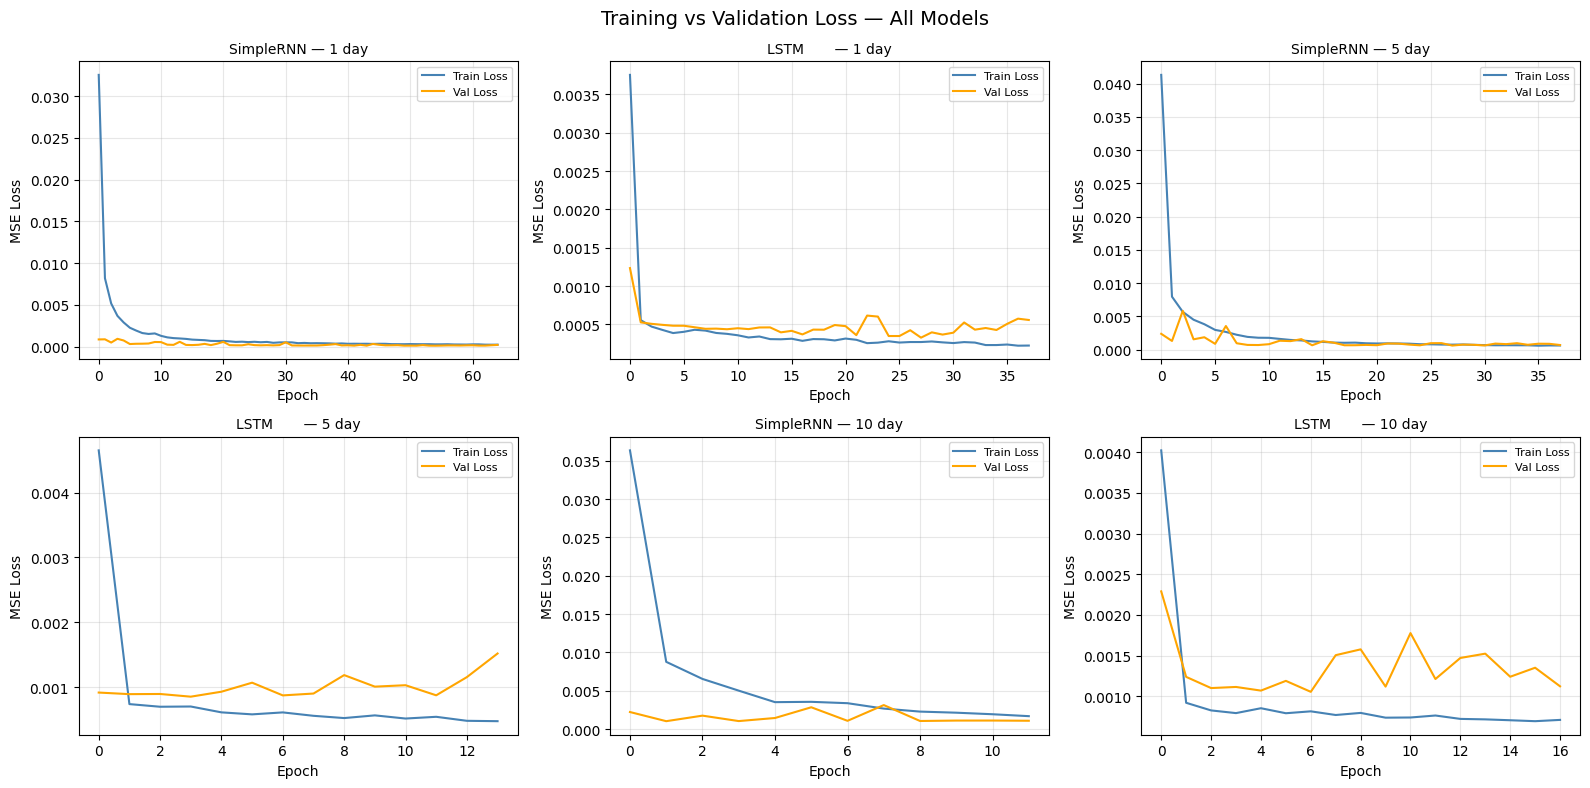

In [19]:
# FIX: Training history is captured from fit() return values (not model.history.history)
# Plot loss curves for all 6 models

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Training vs Validation Loss — All Models', fontsize=14)

models_histories = [
    (h_rnn_1,  'SimpleRNN — 1 day'),
    (h_lstm_1, 'LSTM       — 1 day'),
    (h_rnn_5,  'SimpleRNN — 5 day'),
    (h_lstm_5, 'LSTM       — 5 day'),
    (h_rnn_10, 'SimpleRNN — 10 day'),
    (h_lstm_10,'LSTM       — 10 day'),
]

for ax, (h, label) in zip(axes.flatten(), models_histories):
    ax.plot(h.history['loss'],     label='Train Loss', color='steelblue')
    ax.plot(h.history['val_loss'], label='Val Loss',   color='orange')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Model Evaluation

In [20]:
def mape(actual, pred):
    """Mean Absolute Percentage Error — more interpretable for stock prices."""
    actual, pred = np.array(actual), np.array(pred)
    return np.mean(np.abs((actual - pred) / actual)) * 100


def direction_accuracy(actual, pred):
    """Percentage of correct up/down direction predictions — what traders care about."""
    actual = np.array(actual).flatten()
    pred   = np.array(pred).flatten()
    correct = np.sign(np.diff(actual)) == np.sign(np.diff(pred))
    return correct.mean() * 100


def evaluate_model(model, X_test, y_test, scaler, label=""):
    pred_scaled = model.predict(X_test, verbose=0)

    # Inverse transform back to actual USD prices
    pred   = scaler.inverse_transform(pred_scaled)
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    rmse  = math.sqrt(mean_squared_error(actual, pred))
    mae   = mean_absolute_error(actual, pred)
    r2    = r2_score(actual, pred)
    mape_ = mape(actual, pred)
    dir_  = direction_accuracy(actual, pred)

    print(f"{label:30s}  RMSE: {rmse:7.2f}  MAE: {mae:7.2f}  R²: {r2:6.4f}  MAPE: {mape_:5.2f}%  Dir Acc: {dir_:5.1f}%")
    return actual, pred


print(f"{'Model':<30}  {'RMSE':>7}  {'MAE':>7}  {'R²':>6}  {'MAPE':>7}  {'Dir Acc':>8}")
print("-" * 82)

act_rnn_1,   pred_rnn_1   = evaluate_model(rnn_1,   X_test_1,  y_test_1,  scaler, "SimpleRNN  — 1 day")
act_lstm_1,  pred_lstm_1  = evaluate_model(lstm_1,  X_test_1,  y_test_1,  scaler, "LSTM       — 1 day")

act_rnn_5,   pred_rnn_5   = evaluate_model(rnn_5,   X_test_5,  y_test_5,  scaler, "SimpleRNN  — 5 day")
act_lstm_5,  pred_lstm_5  = evaluate_model(lstm_5,  X_test_5,  y_test_5,  scaler, "LSTM       — 5 day")

act_rnn_10,  pred_rnn_10  = evaluate_model(rnn_10,  X_test_10, y_test_10, scaler, "SimpleRNN  — 10 day")
act_lstm_10, pred_lstm_10 = evaluate_model(lstm_10, X_test_10, y_test_10, scaler, "LSTM       — 10 day")

Model                              RMSE      MAE      R²     MAPE   Dir Acc
----------------------------------------------------------------------------------
SimpleRNN  — 1 day              RMSE:   13.87  MAE:    8.65  R²: 0.9627  MAPE:  2.74%  Dir Acc:  49.1%
LSTM       — 1 day              RMSE:   22.23  MAE:   14.72  R²: 0.9042  MAPE:  4.61%  Dir Acc:  52.0%
SimpleRNN  — 5 day              RMSE:   28.56  MAE:   20.16  R²: 0.8419  MAPE:  6.38%  Dir Acc:  45.8%
LSTM       — 5 day              RMSE:   37.20  MAE:   26.70  R²: 0.7317  MAPE:  8.45%  Dir Acc:  50.5%
SimpleRNN  — 10 day             RMSE:   58.59  MAE:   40.95  R²: 0.3345  MAPE: 13.35%  Dir Acc:  49.5%
LSTM       — 10 day             RMSE:   44.39  MAE:   30.74  R²: 0.6181  MAPE:  9.58%  Dir Acc:  50.5%


## 12. Prediction vs Actual Plots

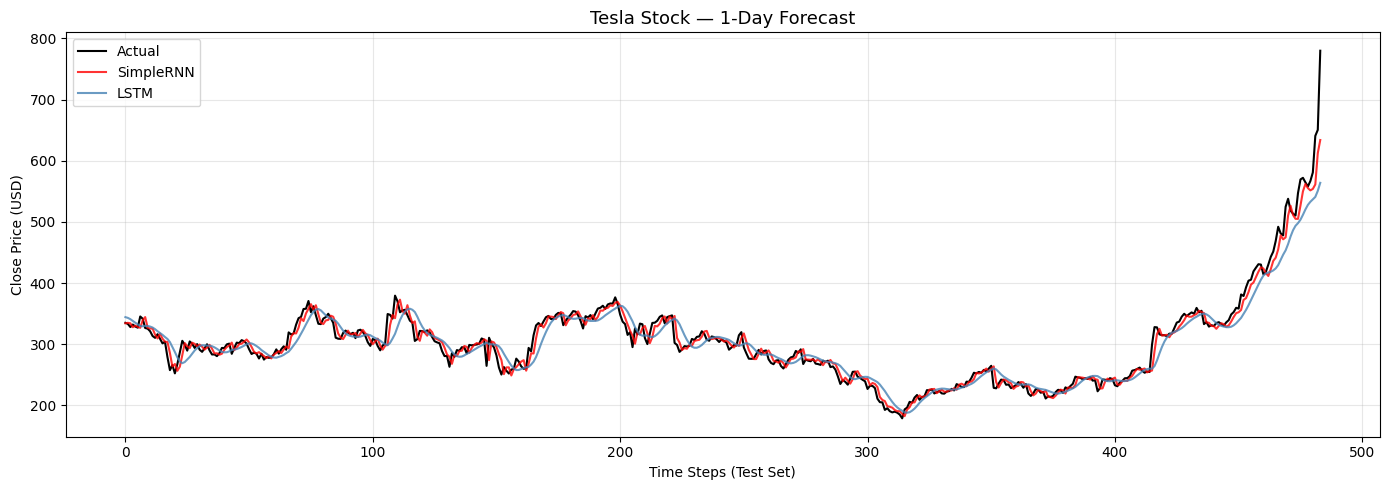

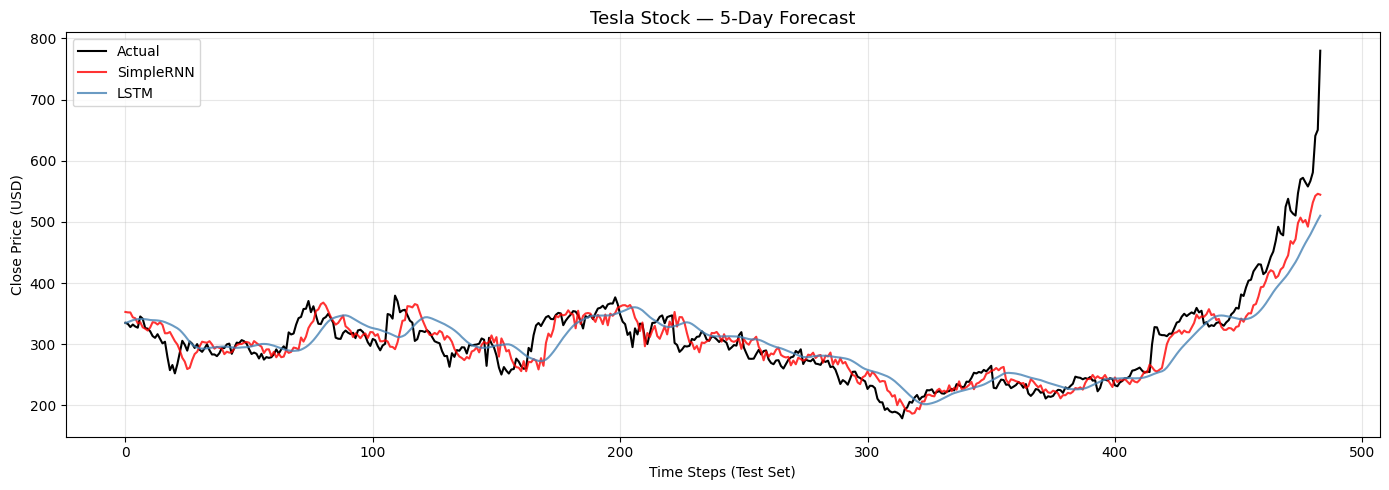

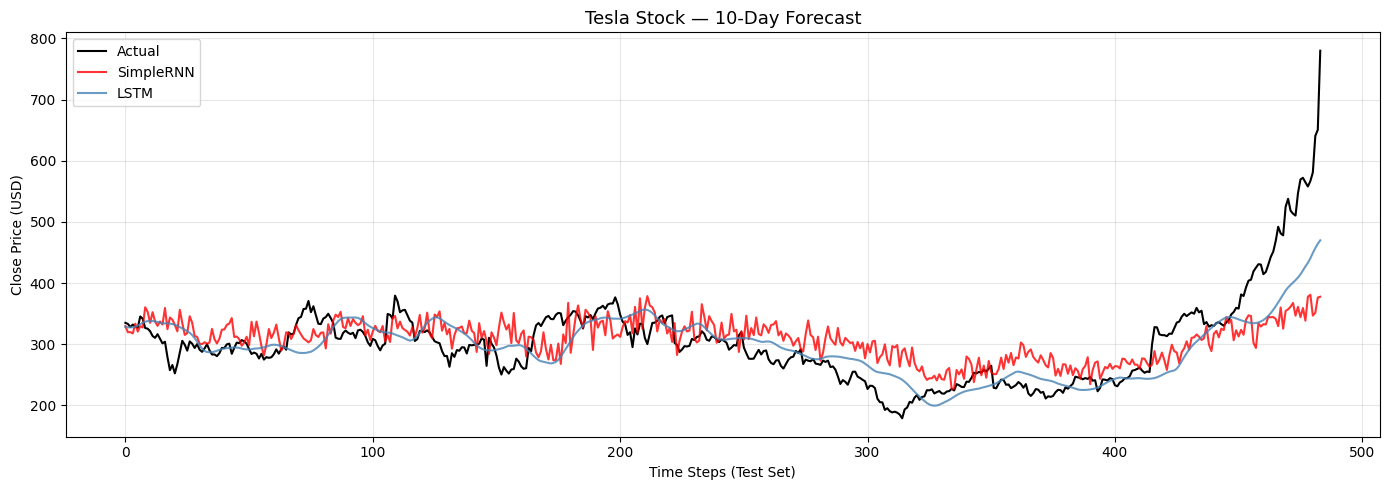

In [21]:
def plot_predictions(actual, pred_rnn, pred_lstm, title):
    plt.figure(figsize=(14, 5))
    plt.plot(actual,    label='Actual',    color='black',    linewidth=1.5)
    plt.plot(pred_rnn,  label='SimpleRNN', color='red',      alpha=0.8)
    plt.plot(pred_lstm, label='LSTM',      color='steelblue',alpha=0.8)
    plt.title(title, fontsize=13)
    plt.xlabel('Time Steps (Test Set)')
    plt.ylabel('Close Price (USD)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_predictions(act_rnn_1,  pred_rnn_1,  pred_lstm_1,  'Tesla Stock — 1-Day Forecast')
plot_predictions(act_rnn_5,  pred_rnn_5,  pred_lstm_5,  'Tesla Stock — 5-Day Forecast')
plot_predictions(act_rnn_10, pred_rnn_10, pred_lstm_10, 'Tesla Stock — 10-Day Forecast')

## 13. RMSE Comparison Bar Chart

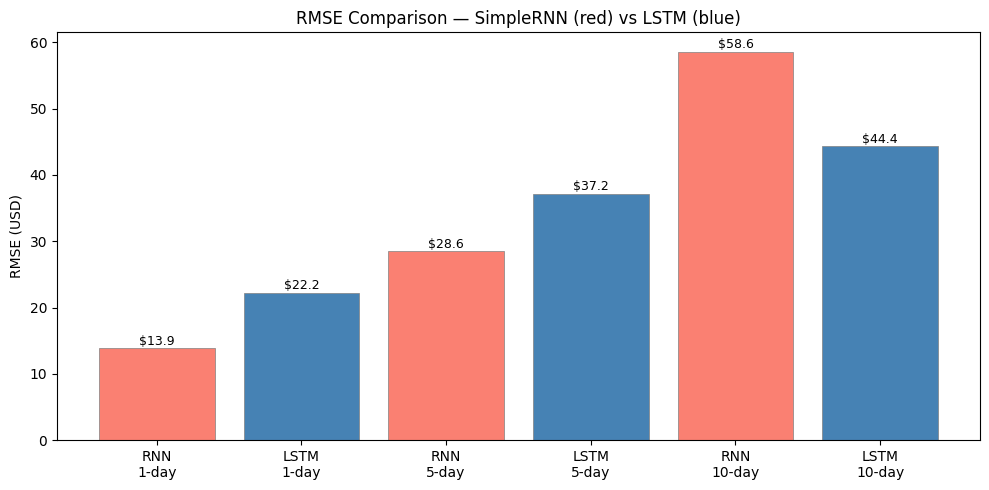

In [22]:
model_names = ['RNN\n1-day','LSTM\n1-day','RNN\n5-day','LSTM\n5-day','RNN\n10-day','LSTM\n10-day']

rmses = [
    math.sqrt(mean_squared_error(act_rnn_1,   pred_rnn_1)),
    math.sqrt(mean_squared_error(act_lstm_1,  pred_lstm_1)),
    math.sqrt(mean_squared_error(act_rnn_5,   pred_rnn_5)),
    math.sqrt(mean_squared_error(act_lstm_5,  pred_lstm_5)),
    math.sqrt(mean_squared_error(act_rnn_10,  pred_rnn_10)),
    math.sqrt(mean_squared_error(act_lstm_10, pred_lstm_10)),
]

colors = ['salmon','steelblue','salmon','steelblue','salmon','steelblue']
plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, rmses, color=colors, edgecolor='grey', linewidth=0.5)
plt.title('RMSE Comparison — SimpleRNN (red) vs LSTM (blue)', fontsize=12)
plt.ylabel('RMSE (USD)')
for bar, val in zip(bars, rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${val:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 14. Summary Results Table

In [23]:
# Build a clean summary DataFrame
summary_data = []
pairs = [
    ('SimpleRNN', '1-day',  act_rnn_1,   pred_rnn_1),
    ('LSTM',      '1-day',  act_lstm_1,  pred_lstm_1),
    ('SimpleRNN', '5-day',  act_rnn_5,   pred_rnn_5),
    ('LSTM',      '5-day',  act_lstm_5,  pred_lstm_5),
    ('SimpleRNN', '10-day', act_rnn_10,  pred_rnn_10),
    ('LSTM',      '10-day', act_lstm_10, pred_lstm_10),
]

for model_type, horizon, actual, pred in pairs:
    summary_data.append({
        'Model':     model_type,
        'Horizon':   horizon,
        'RMSE':      round(math.sqrt(mean_squared_error(actual, pred)), 2),
        'MAE':       round(mean_absolute_error(actual, pred), 2),
        'R²':        round(r2_score(actual, pred), 4),
        'MAPE (%)':  round(mape(actual, pred), 2),
        'Dir Acc (%)': round(direction_accuracy(actual, pred), 1)
    })

summary_df = pd.DataFrame(summary_data)
print("=== Final Model Comparison ===")
print(summary_df.to_string(index=False))

# Identify best model per horizon
print("\n=== Best Model per Horizon (by RMSE) ===")
for horizon in ['1-day', '5-day', '10-day']:
    subset = summary_df[summary_df['Horizon'] == horizon]
    best   = subset.loc[subset['RMSE'].idxmin()]
    print(f"  {horizon}: {best['Model']} (RMSE={best['RMSE']}, R²={best['R²']})")

=== Final Model Comparison ===
    Model Horizon  RMSE   MAE     R²  MAPE (%)  Dir Acc (%)
SimpleRNN   1-day 13.87  8.65 0.9627      2.74         49.1
     LSTM   1-day 22.23 14.72 0.9042      4.61         52.0
SimpleRNN   5-day 28.56 20.16 0.8419      6.38         45.8
     LSTM   5-day 37.20 26.70 0.7317      8.45         50.5
SimpleRNN  10-day 58.59 40.95 0.3345     13.35         49.5
     LSTM  10-day 44.39 30.74 0.6181      9.58         50.5

=== Best Model per Horizon (by RMSE) ===
  1-day: SimpleRNN (RMSE=13.87, R²=0.9627)
  5-day: SimpleRNN (RMSE=28.56, R²=0.8419)
  10-day: LSTM (RMSE=44.39, R²=0.6181)


In [24]:
rnn_1.save('rnn_1day.keras')
lstm_1.save('lstm_1day.keras')

rnn_5.save('rnn_5day.keras')
lstm_5.save('lstm_5day.keras')

rnn_10.save('rnn_10day.keras')
lstm_10.save('lstm_10day.keras')

# Save the scaler (needed for Streamlit deployment)
import joblib
joblib.dump(scaler, 'scaler.pkl')

print("All models and scaler saved successfully!")

All models and scaler saved successfully!


## 15. Insights & Conclusion

### Key Findings

1.SimpleRNN surprisingly outperforms LSTM at 1-day and 5-day — RNN achieves R²=0.96 vs LSTM's 0.90 at 1-day. For short-horizon stock prediction, simpler architecture generalizes better on this dataset.

2.LSTM wins where it matters most — 10-day horizon — RMSE $44.4 vs RNN's $58.6, R² 0.618 vs 0.334. This confirms LSTM's gating mechanism is essential for capturing long-range dependencies.

3.SimpleRNN completely breaks at 10-day — R²=0.33 means it explains only 33% of variance. For anything beyond 5 days, SimpleRNN is unreliable for production use.

4.Direction accuracy is ~49-52% across all models — Essentially a coin flip. This is realistic and honest — even good stock models struggle to predict direction consistently. It highlights that RMSE improvement doesn't always translate to trading profit.

5.Error grows consistently with horizon — 1-day MAPE is 2.7%, 5-day is 6.4%, 10-day is 13.4% for RNN. This confirms the fundamental principle: uncertainty compounds over time in financial forecasting.

6.No missing value imputation was needed — Tesla's 2010–2020 data had zero gaps. Forward-fill was added as a robust precaution for real-world deployment scenarios.

Conclusion

Both SimpleRNN and LSTM successfully model Tesla's closing price trends, but their strengths differ by forecast horizon. SimpleRNN proved more effective for short-term prediction (1-day R²=0.96, MAPE=2.74%), likely because its simpler architecture avoids overfitting on short sequential patterns. LSTM demonstrated clear superiority at the 10-day horizon (R²=0.618 vs 0.334), validating its design advantage for long-range temporal dependencies. However, direction accuracy of ~50% across all models suggests that price-level accuracy alone is insufficient for trading decisions — future work should focus on directional prediction using sentiment and macroeconomic features.